## Simulating traffic around a lock
In this notebook, we simulate a lock on a network which two opposingly directed vessels have to pass. We add a pre-coded complex lock object on the graph: only one vessel can be levelled at a time. The second vessel waits until the first vessel has passed the lock. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart

# import of modules important for locking
from opentnsim.lock import lock_new as lock_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.graph.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 2. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad, Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad, Point(5000,0)))

# add edges
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1)
graph.add_edge('1','0', weight=1); #it is not required to have a geometry

In [4]:
opentnsim.graph.plot_graph(graph)

#### 3. Run simulation

In [5]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [6]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
env.graph = graph

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=graph, crs_m="4087")

lock = lock_module.IsLockComplex(
    env=env,
    name='Lock',
    node_open='0',
    node_A = '0',
    node_B = '1',
    distance_lock_doors_A_to_waiting_area_A = 4800,
    distance_lock_doors_B_to_waiting_area_B = 4800,
    distance_from_start_node_to_lock_doors_A = 4800,
    distance_from_end_node_to_lock_doors_B = 4800,
    lock_length = 400,
    lock_width = 50,
    lock_depth = 15,
    levelling_time = 300,
    sailing_distance_to_crossing_point = 1800,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.5,
    sailing_in_time_gap_through_doors = 300,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 120,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    registration_nodes = ['0','1'],
    predictive=False
)

# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 10,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 10,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.run()

In [7]:
lock.vessel_planning

,id,bound,L,B,T,operation_index,time_of_registration,time_of_acceptance,time_arrival_at_waiting_area,time_arrival_at_lineup_area,time_lock_passing_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_passing_stop,delay,time_potential_lock_door_opening_stop,time_potential_lock_door_closure_start
0,2d06c8c6-06f9-4506-bf71-856d0163307c,0,100,20,10,0,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,NaN,2025-01-01 00:12:30,2025-01-01 00:20:00,2025-01-01 00:25:40.172786470,2025-01-01 00:40:40.172786470,2025-01-01 00:41:28.768898822,2025-01-01 00:48:58.768898822,0 days 00:00:00,2025-01-01 00:10:00.000000000,2025-01-01 00:25:40.172786470
1,bf20bcb8-1442-4f90-b6d9-e01856e005dd,1,100,20,10,1,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,NaN,2025-01-01 00:48:58.768898822,2025-01-01 00:56:28.768898822,2025-01-01 01:02:08.941685292,2025-01-01 01:17:08.941685292,2025-01-01 01:17:57.537797644,2025-01-01 01:25:27.537797644,0 days 00:36:28.768898822,2025-01-01 00:46:28.768898822,2025-01-01 01:02:08.941685292


In [8]:
lock.operation_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,[<__main__.Vessel object at 0x0000018559413F40>],300,30,2025-01-01 00:10:00,2025-01-01 00:12:30,2025-01-01 00:20:00,2025-01-01 00:25:40.172786470,2025-01-01 00:25:40.172786470,2025-01-01 00:30:40.172786470,...,2025-01-01 00:40:40.172786470,2025-01-01 00:40:40.172786470,2025-01-01 00:41:28.768898822,2025-01-01 00:48:58.768898822,2025-01-01 00:43:28.768898822,NaN,NaN,0 days 00:00:00,0 days 00:00:00,ready
1,1,[<__main__.Vessel object at 0x0000018559445240>],300,30,2025-01-01 00:46:28.768898822,2025-01-01 00:48:58.768898822,2025-01-01 00:56:28.768898822,2025-01-01 01:02:08.941685292,2025-01-01 01:02:08.941685292,2025-01-01 01:07:08.941685292,...,2025-01-01 01:17:08.941685292,2025-01-01 01:17:08.941685292,2025-01-01 01:17:57.537797644,2025-01-01 01:25:27.537797644,2025-01-01 01:19:57.537797644,NaN,NaN,0 days 00:36:28.768898822,0 days 00:36:28.768898822,ready


#### 4. Inspect output

In [9]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2025-01-01 00:00:00.000000,0,POINT (-0.0449157642059761 0)
1,Sailing to first lock doors start,2025-01-01 00:00:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0449157642059761 0)
2,Sailing to first lock doors stop,2025-01-01 00:20:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.001796630568239 0)
3,Sailing to position in lock start,2025-01-01 00:20:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.001796630568239 0)
4,Sailing to position in lock stop,2025-01-01 00:25:40.172786,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
5,Levelling start,2025-01-01 00:30:40.172786,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
6,Levelling stop,2025-01-01 00:35:40.172786,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
7,Sailing to second lock doors start,2025-01-01 00:40:40.172786,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
8,Sailing to second lock doors stop,2025-01-01 00:41:28.768899,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)
9,Sailing to lock complex exit start,2025-01-01 00:41:28.768899,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)


In [10]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 1 to node 0 start,2025-01-01 00:00:00.000000,0,POINT (0.0449157642059761 0)
1,Waiting for lock operation start,2025-01-01 00:00:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0449157642059761 0)
2,Waiting for lock operation stop,2025-01-01 00:36:28.768898,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0449157642059761 0)
3,Sailing to first lock doors start,2025-01-01 00:36:28.768898,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0449157642059761 0)
4,Sailing to first lock doors stop,2025-01-01 00:56:28.768898,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)
5,Sailing to position in lock start,2025-01-01 00:56:28.768898,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)
6,Sailing to position in lock stop,2025-01-01 01:02:08.941684,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)
7,Levelling start,2025-01-01 01:07:09.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)
8,Levelling stop,2025-01-01 01:12:09.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)
9,Sailing to second lock doors start,2025-01-01 01:17:09.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)


In [11]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock.logbook)

print("'{}' logbook data:".format(lock.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock doors closing start,2025-01-01 00:25:40.172786,{},0
1,Lock doors closing stop,2025-01-01 00:30:40.172786,{},0
2,Lock chamber converting start,2025-01-01 00:30:40.172786,{},0
3,Lock chamber converting stop,2025-01-01 00:35:40.172786,{},1
4,Lock doors opening start,2025-01-01 00:35:40.172786,{},1
5,Lock doors opening stop,2025-01-01 00:40:40.172786,{},1
6,Lock doors closing start,2025-01-01 01:02:09.000000,{},1
7,Lock doors closing stop,2025-01-01 01:07:09.000000,{},1
8,Lock chamber converting start,2025-01-01 01:07:09.000000,{},1
9,Lock chamber converting stop,2025-01-01 01:12:09.000000,{},0


In [12]:
%load_ext autoreload
%autoreload 2

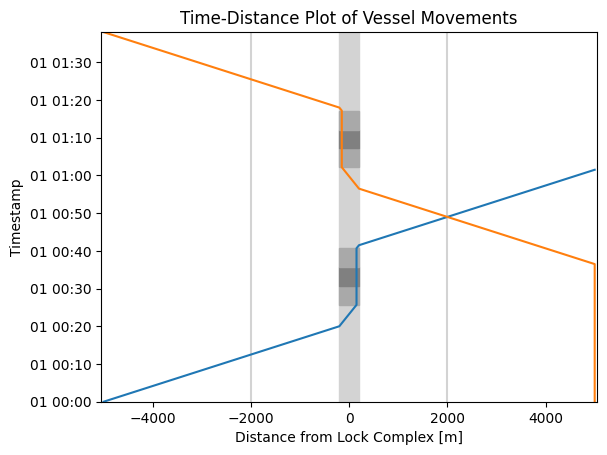

In [13]:
# We can plot the time-distance diagram
fig = lock.create_time_distance_plot(vessels = [vessel_1,vessel_2], 
                                     xlimmin = -5050, 
                                     xlimmax = 5050)

In [14]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([vessel_1, vessel_2, lock])
generate_vessel_gantt_chart(df_eventtable)